# 3.6 Multivariable Regression

This notebook is adapted from the code taken from

https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_network_sine_learning/nn_learns_sine_function_with_autodiff_in_julia_lux.jl


Here, we will repeat what was done in the previous notebook but for function of 2 variables.  

$y=f(x_1,x_2)$


In [3]:
using Random
using Zygote
#using Optimisers
using Optimization
using OptimizationOptimisers
using CairoMakie
using Distributions
using Statistics

Defining constants from training and architecture of the Neural Network

In [4]:
N_SAMPLES = 100 #number of samples
LEARNING_RATE = 0.1
N_EPOCHS = 1_000 #epochs is the number of times the algorithm "sees" all your data

1000

* Again, here, we will draw  samples to create a toy data set. 
* We will use data generated from the functional form $y=2x_1x_2+x_2^2$

In [5]:
# Our Pseudo-Random Number Generator
rng = Xoshiro(42)

x1_samples = rand(
    rng,
    Uniform(0.0, 2 * π),
    (1,N_SAMPLES),
)

x2_samples = rand(
    rng,
    Uniform(0.0, 2 * π),
    (1,N_SAMPLES),
)


y_noise = rand(
    rng,
    Normal(0.0, 0.01),
    (1,N_SAMPLES),
)

y_samples = 2.0*x1_samples.*x2_samples+x2_samples.^2


1×100 Matrix{Float64}:
 50.3952  0.334151  37.9588  9.30317  …  12.5818  65.0081  5.95607  28.8562

Note that `x1_samples`, `x2_samples` and `y_samples` are column vectors of length  N_SAMPLES.

We will now plot the data to see how it looks like.

Note that we have to use `tricontourf!()` instead of `contourf!()` because the data is at random location of $(x_1,x_2)$.  If the $x_1$ and $x_2$ are structured and taken from a rectangular mesh, then you can use `contour!()`

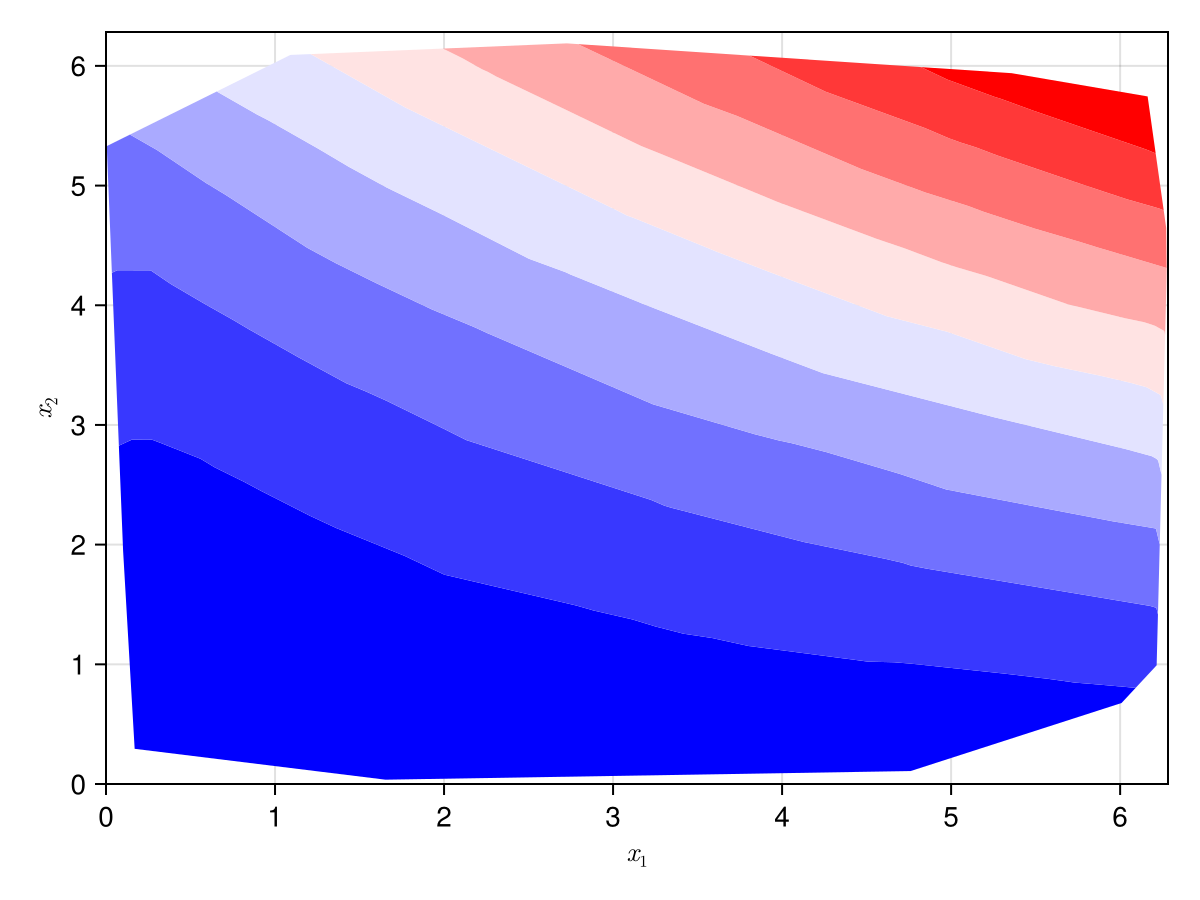

In [7]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax,x1_samples[:],x2_samples[:],y_samples[:],colormap=:bwr)
fig

In this example, we will define our model as

$f_{model}(x_1,x_2)=a_0+a_1 x_1+a_2 x_2+a_3x_1x_2+a_4 x_1^2+a_5 x_2^2$

Hence, our objective now is to find $a_0, a_1, a_2$,  $a_3$, $a_4$ and $a_5$ such that $f_{model}(x_1,x_2)$ closely approximates $y(x_1,x_2)$. Since we fictitiously generated our data using the function $y=2x_1x_2+x_2^2$, our solution should 

$a_0=0.0$

$a_1=0.0$

$a_2=0.0$

$a_3=2.0$ 

$a_4=0.0$ and 

$a_5=1.0$.

 Remember that $a_0 \rightarrow $ a[1], $a_1 \rightarrow $ a[2].....since the indices in Julia starts with 1.

In defining the function below, we will assume that the input data will be in the form of the matrix


$\mathbf{x}=\begin{bmatrix} x_{11} &x _{12} & x_{13} & \cdots &x_{1N} \\ x_{21} &x _{22} & x_{23} & \cdots &x_{2N} \end{bmatrix}$

The first row of this matrix consist of all the data for $x_1$ and the second row of this matrix has the data for $x_2$.  This because later on when we use the Neural Network in Julia, the input is expected in the same form.  The output vector should be evaluated as $f_{model}(x_{1i},x_{2i})=f_i$.  The predicted output and the model output should be in row format as well

$\mathbf{y}=\begin{bmatrix} y_{1} &y _{2} & y_{3} & \cdots &y_{N} \end{bmatrix}$


In [8]:
fmodel(a,x)=(a[1].+a[2]*x[1,:]+a[3]*x[2,:]+a[4]*x[1,:].*x[2,:]+a[5]*x[1,:].^2+a[6]*x[2,:].^2)'

fmodel (generic function with 1 method)

In real life, we do not know what my $a_i$'s are, so I will assume that that they are all 1.0.

In [9]:
a=[1.0,1.0,1.0,1.0,1.0,1.0] #by memory from memory
input_matrix=vcat(x1_samples[:]',x2_samples[:]') 
y_prediction=fmodel(a,input_matrix)

1×100 adjoint(::Vector{Float64}) with eltype Float64:
 53.1233  7.35714  40.2577  12.3429  …  34.3747  65.7091  9.01162  33.0588

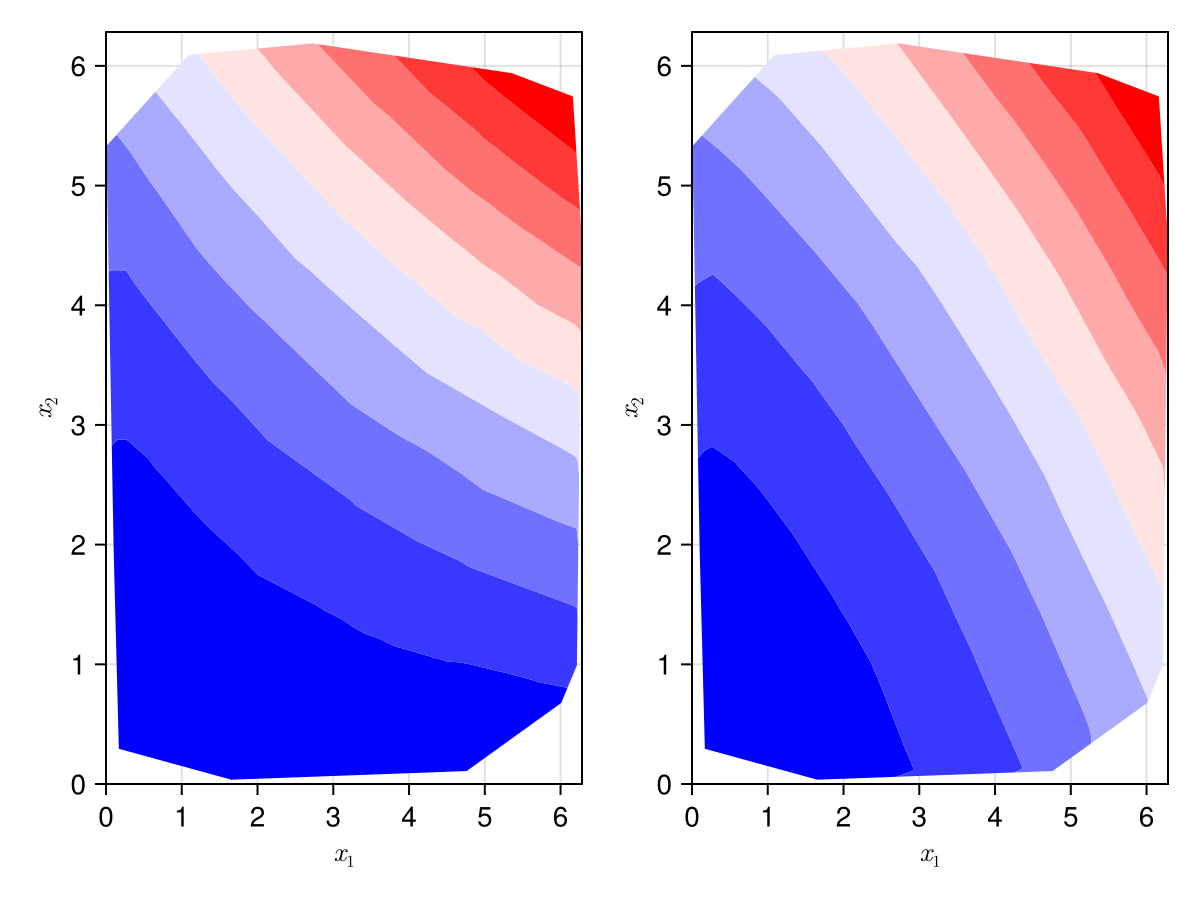

In [10]:
fig = Figure()
ax1 = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax1,x1_samples[:],x2_samples[:],y_samples[:],colormap=:bwr)

ax2 = Axis(fig[1, 2], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax2,x1_samples[:],x2_samples[:],y_prediction[:],colormap=:bwr)


fig


The left figure is the data and the right figure is the initial $f_{model}$ prediction.  The prediction is not good which is expected because the parameters are random.

We now set up the loss/objective/cost function

In [11]:
# The forward function
function loss_fn(a,input_matrix)
    y_prediction = fmodel(a,input_matrix)
    loss = 0.5 * mean((y_prediction .- y_samples).^2)
    return loss
end

loss_fn (generic function with 1 method)

Predict the initial loss to check that the loss function is working

In [12]:
loss=loss_fn(a,input_matrix)

125.65142488978641

In [13]:
function my_callback(state, l)
    push!(loss_history, l)
    return false # continues the solver
end

optf = OptimizationFunction(loss_fn, ADTypes.AutoZygote())
prob = OptimizationProblem(optf,a,input_matrix)
loss_history = []
sol = solve(prob, Optimisers.Adam(0.001,(0.9,0.99));maxiters=20000,callback=my_callback);
sol.u

6-element Vector{Float64}:
 1.7247337502511296e-10
 1.7249039067590827e-10
 1.7249096373986039e-10
 2.0000000001724945
 1.7249341263514243e-10
 1.0000000001724951

Note that Julia has fond that $a_3 \approx 2.0$ and $a_5 \approx 1.0$, which we know is correct for this problem

Plot loss history

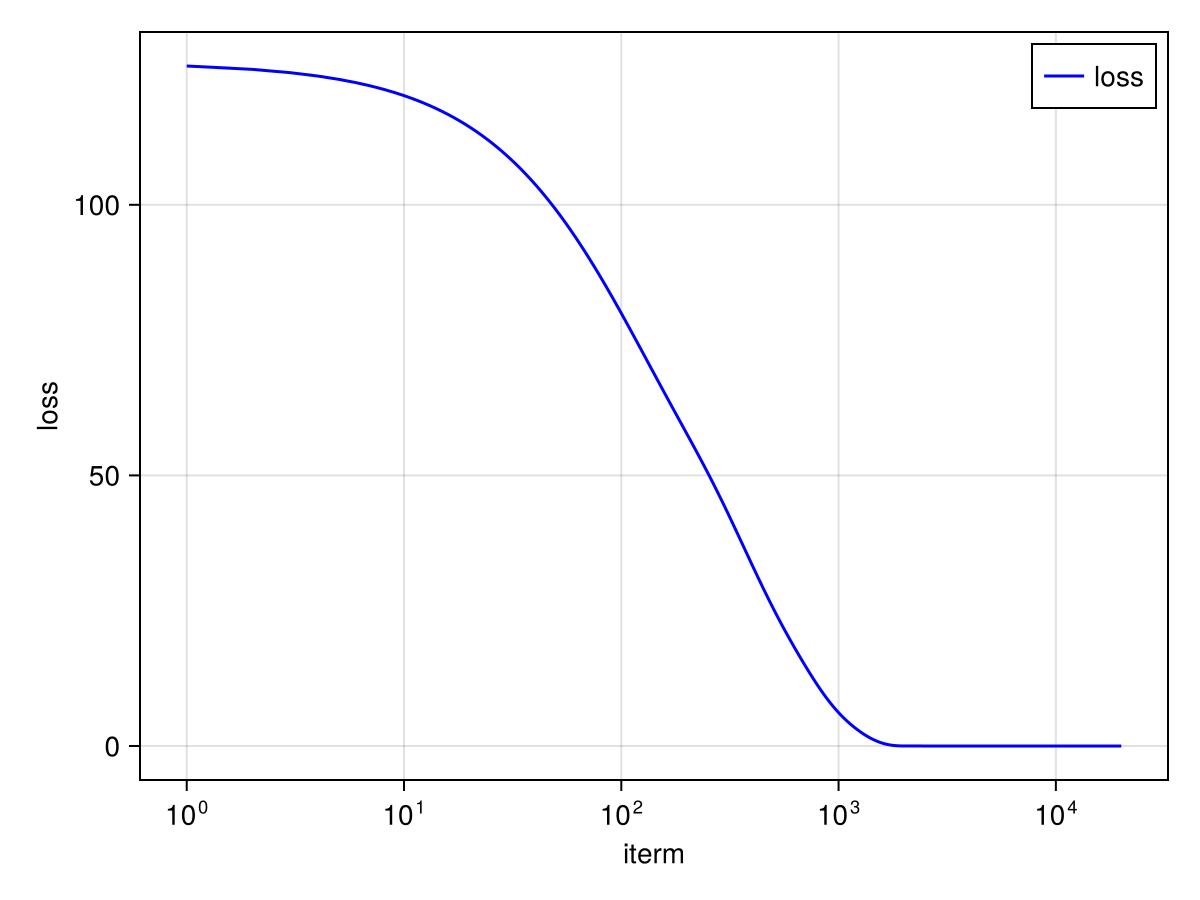

In [14]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "iterm", ylabel = "loss",xscale=log10)
lines!(ax,loss_history;color=:blue,label="loss")

axislegend(ax,  position = :rt,orientation = :vertical)
fig

the value of the loss function is very small after about 2-3000 iterations

Plot final solution and compare with ground truth

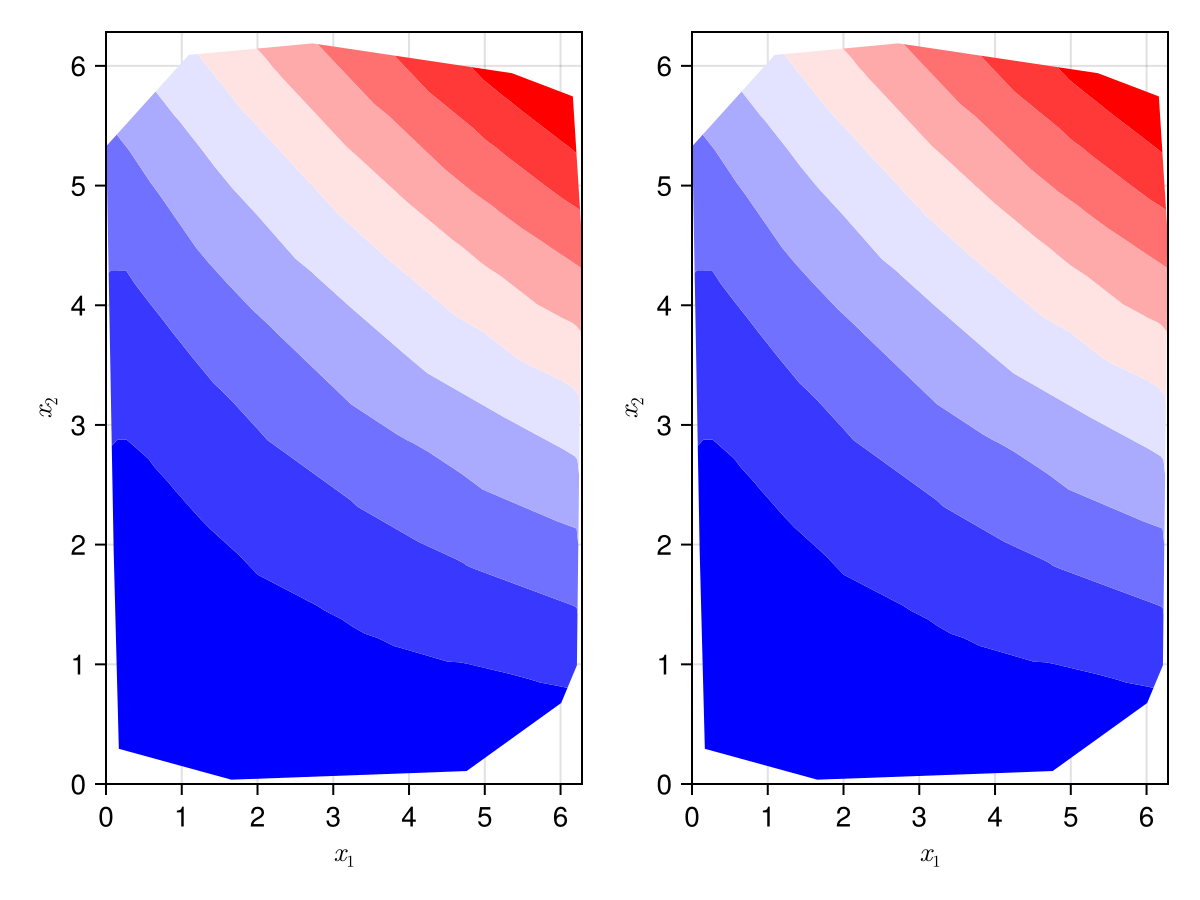

In [15]:
fig = Figure()
ax1 = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax1,x1_samples[:],x2_samples[:],y_samples[:],colormap=:bwr )

y_prediction=fmodel(sol.u,input_matrix)

ax2 = Axis(fig[1, 2], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax2,x1_samples[:],x2_samples[:],y_prediction[:],colormap=:bwr)


fig

---

**Class Demo 01:**  Repeat the exercise above (using the same $f_{model}(x_1,x_2)=a_0+a_1 x_1+a_2 x_2+a_3x_1x_2+a_4 x_1^2+a_5 x_2^2$  with the fictitious data set $y=\sin(x_1x_2)$?  Consider the domain $x_1\in[0,2\pi]$ and $x_2\in[0,2\pi]$

---